# 🚛 Concrete Mixer Truck — Complete OBB Pipeline (Production)
## YOLO-World Auto-Labeling → Data Fusion → OBB Training → Drum Rotation Detection

**Pipeline overview**
| Phase | Description |
|---|---|
| 1 | YOLO-World zero-shot auto-labeling → OBB format |
| 2 | Data fusion: merge datasets + convert YOLO6 → OBB 9-value |
| 3 | Two-stage OBB training with `yolo26n-obb.pt` + MLflow |
| 4 | Per-drum ROI crop → Optical Flow + SSIM rotation detection |

**Dataset structure expected**
```
data/
  Mixer.yolo26/
    train/images/*.jpg
    train/labels/*.txt   ← YOLO6 format (5 values) or OBB (9 values)
    valid/images/
    valid/labels/
  concrete mixed truck.yolo26/
    train/images/
    train/labels/
    valid/images/
    valid/labels/
```


In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
import subprocess, sys

pkgs = [
    "ultralytics>=8.3.0",
    "opencv-python-headless",
    "pyyaml",
    "mlflow",
    "scikit-image",
    "tqdm",
    "matplotlib",
    "numpy",
]

for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

print("✅ All packages installed")


✅ All packages installed


In [2]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────────
import os, sys, cv2, random, shutil, yaml, time, logging, warnings
import numpy as np
import mlflow
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from collections import Counter, defaultdict
from tqdm.auto import tqdm
from skimage.metrics import structural_similarity as ssim

warnings.filterwarnings("ignore")
logging.getLogger("ultralytics").setLevel(logging.WARNING)
logging.getLogger("mlflow").setLevel(logging.WARNING)

# ── Try importing ultralytics ──────────────────────────────────────────────────
try:
    from ultralytics import YOLO, YOLOWorld
    print(f"✅ Ultralytics OK")
except ImportError as e:
    print(f"❌ ultralytics import failed: {e}")
    print("   Run: pip install ultralytics>=8.3.0")
    raise

%matplotlib inline
print("✅ All imports successful")


C:\Users\supaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydantic\_internal\_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


✅ Ultralytics OK
✅ All imports successful


In [15]:
# ── Cell 3: Configuration (edit here) ─────────────────────────────────────────
@dataclass
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────────
    data_dir:          str = "./data"
    auto_labeled_dir:  str = "./auto_labeled"
    merged_dir:        str = "./merged_dataset_obb"
    mlruns_dir:        str = "./mlruns"
    output_dir:        str = "./outputs"

    # ── Dataset names (folders inside data_dir) ───────────────────────────────
    dataset_1_name:    str = "Mixer.yolo26"
    dataset_2_name:    str = "concrete mixed truck.yolo26"

    # ── Classes  (index must match YOLO-World set_classes order) ──────────────
    class_names:       List[str] = field(default_factory=lambda: ["truck", "mixer_drum"])
    # class 0 = truck | class 1 = mixer_drum

    # ── OBB Model ─────────────────────────────────────────────────────────────
    model_name:        str = "yolo26n-obb.pt"   # latest YOLO26 OBB nano
    input_size:        int = 640
    batch_size:        int = 4
    total_epochs:      int = 50
    freeze_epochs:     int = 20                 # Stage-1 (freeze backbone)
    lr0:               float = 0.01
    lrf:               float = 0.001
    workers:           int = 2
    device:            str = "cpu"             # "0" for GPU, "cpu" for CPU

    # ── YOLO-World auto-labeling ───────────────────────────────────────────────
    yoloworld_model:   str = "yolov8x-worldv2.pt"
    yoloworld_classes: List[str] = field(default_factory=lambda: ["truck", "concrete mixer drum"])
    labeling_conf:     float = 0.15            # low conf = more recall

    # ── MLflow ────────────────────────────────────────────────────────────────
    experiment_name:   str = "concrete_mixer_obb"

    # ── Rotation detection thresholds ─────────────────────────────────────────
    flow_mag_threshold:  float = 1.5           # Farneback mean magnitude
    ssim_threshold:      float = 0.88          # below → motion detected
    curl_threshold:      float = 0.3           # curl score → rotational motion
    min_drum_area:       int   = 32 * 32       # ignore tiny detections (px²)

    # ── Augmentation ─────────────────────────────────────────────────────────
    degrees:    float = 45.0
    perspective: float = 0.001
    scale:      float = 0.5
    mosaic:     float = 1.0
    mixup:      float = 0.1
    fliplr:     float = 0.5
    hsv_h:      float = 0.015
    hsv_s:      float = 0.7
    hsv_v:      float = 0.4

cfg = Config()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
print("✅ Config loaded")
print(f"   Model      : {cfg.model_name}")
print(f"   Classes    : {cfg.class_names}")
print(f"   Epochs     : {cfg.total_epochs}  (freeze {cfg.freeze_epochs} + finetune {cfg.total_epochs - cfg.freeze_epochs})")
print(f"   Device     : {cfg.device}")

✅ Config loaded
   Model      : yolo26n-obb.pt
   Classes    : ['truck', 'mixer_drum']
   Epochs     : 50  (freeze 20 + finetune 30)
   Device     : cpu


In [16]:
# ── Cell 4: Utility helpers ───────────────────────────────────────────────────

def find_images(folder: Path) -> List[Path]:
    """Recursively collect all image files in a folder."""
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return [p for p in folder.rglob("*") if p.suffix.lower() in exts]

def label_path_for(img_path: Path) -> Path:
    """Return expected label .txt given an image path."""
    return img_path.parent.parent / "labels" / f"{img_path.stem}.txt"

def safe_copy(src: Path, dst: Path):
    """Copy file; skip if src==dst; create parent dirs."""
    dst.parent.mkdir(parents=True, exist_ok=True)
    if src.resolve() != dst.resolve():
        shutil.copy2(src, dst)

def yolo6_to_obb9(line: str) -> Optional[str]:
    """
    Convert a YOLO6 label line (5 values: cls cx cy w h)
    to OBB format (9 values: cls x1 y1 x2 y2 x3 y3 x4 y4).
    Returns None if already OBB or invalid.
    """
    parts = line.strip().split()
    if len(parts) == 9:
        return line.strip()          # already OBB
    if len(parts) != 5:
        return None                  # invalid — skip
    cls, cx, cy, w, h = map(float, parts)
    cls = int(cls)
    hx, hy = w / 2, h / 2
    # axis-aligned corners (clock-wise from top-left)
    x1, y1 = cx - hx, cy - hy
    x2, y2 = cx + hx, cy - hy
    x3, y3 = cx + hx, cy + hy
    x4, y4 = cx - hx, cy + hy
    # clamp to [0, 1]
    vals = [max(0.0, min(1.0, v)) for v in [x1,y1,x2,y2,x3,y3,x4,y4]]
    return f"{cls} " + " ".join(f"{v:.6f}" for v in vals)

def ensure_obb_format(label_path: Path) -> int:
    """
    In-place convert label file to OBB-9 format.
    Returns number of lines converted.
    """
    if not label_path.exists():
        return 0
    with open(label_path, "r") as f:
        raw = f.readlines()
    converted, changed = [], 0
    for line in raw:
        line = line.strip()
        if not line:
            continue
        new_line = yolo6_to_obb9(line)
        if new_line is None:
            continue           # drop invalid lines
        converted.append(new_line)
        if new_line != line:
            changed += 1
    with open(label_path, "w") as f:
        f.write("\n".join(converted) + ("\n" if converted else ""))
    return changed

def audit_labels(label_dir: Path) -> Dict[str, Any]:
    """Scan all label files and report column count distribution."""
    files = list(label_dir.glob("*.txt"))
    counter = Counter()
    empty, bad = [], []
    for fp in files:
        lines = [l.strip() for l in fp.read_text().splitlines() if l.strip()]
        if not lines:
            empty.append(fp.name)
            continue
        for l in lines:
            n = len(l.split())
            counter[n] += 1
            if n != 9:
                bad.append((fp.name, n, l[:60]))
    return {"files": len(files), "dist": counter, "empty": empty, "bad": bad}

def print_audit(result: Dict[str, Any]):
    print(f"Total label files : {result['files']}")
    for ncols, cnt in sorted(result["dist"].items()):
        tag = "✅ OBB" if ncols == 9 else "❌ Wrong"
        print(f"  {ncols:2d} cols → {cnt:5d} lines  {tag}")
    if result["empty"]:
        print(f"  ⚠️  {len(result['empty'])} empty files")
    if result["bad"]:
        print(f"  ❌  {len(result['bad'])} bad lines (first 5 shown):")
        for name, n, sample in result["bad"][:5]:
            print(f"      {name}: {n} cols → {sample}")

print("✅ Utility helpers defined")


✅ Utility helpers defined


In [17]:
# ── Cell 5: YOLO-World Auto-Labeler ──────────────────────────────────────────

class YOLOWorldOBBLabeler:
    """
    Zero-shot OBB auto-labeler using YOLO-World.
    Maps detected class names → integer IDs via class_map.
    Outputs 9-value OBB labels (axis-aligned, from xyxy).
    """

    def __init__(self, model_name: str = "yolov8x-worldv2.pt"):
        print(f"  Loading YOLO-World: {model_name} …")
        self.model = YOLOWorld(model_name)
        self.class_map: Dict[str, int] = {}
        print("  ✅ YOLO-World loaded")

    def set_classes(self, target_classes: List[str], class_map: Dict[str, int]):
        """
        target_classes : list of text queries for YOLO-World
                         e.g. ["truck", "concrete mixer drum"]
        class_map      : maps YOLO-World class NAME → final class ID
                         e.g. {"truck": 0, "concrete mixer drum": 1}
        """
        self.model.set_classes(target_classes)
        self.class_map = class_map
        self.target_classes = target_classes
        print(f"  Classes set: {target_classes}")

    def _xyxy_to_obb9(self, xyxy: np.ndarray, img_w: int, img_h: int,
                       cls_id: int) -> str:
        """Convert xyxy pixel bbox → normalized OBB-9 label string."""
        x1, y1, x2, y2 = xyxy
        # Normalize
        nx1, nx2 = x1 / img_w, x2 / img_w
        ny1, ny2 = y1 / img_h, y2 / img_h
        # Four corners (top-left, top-right, bot-right, bot-left)
        vals = [nx1,ny1, nx2,ny1, nx2,ny2, nx1,ny2]
        vals = [max(0.0, min(1.0, v)) for v in vals]
        return f"{cls_id} " + " ".join(f"{v:.6f}" for v in vals)

    def label_image(self, img_path: Path, conf: float = 0.15) -> List[str]:
        """Run detection on one image; return list of OBB-9 label strings."""
        img = cv2.imread(str(img_path))
        if img is None:
            return []
        h, w = img.shape[:2]

        try:
            results = self.model.predict(str(img_path), conf=conf, verbose=False)
        except Exception as e:
            print(f"  ⚠️  Prediction failed for {img_path.name}: {e}")
            return []

        labels = []
        for result in results:
            if result.boxes is None or len(result.boxes) == 0:
                continue
            for box in result.boxes:
                raw_cls = int(box.cls[0].item())
                # Map YOLO-World index → class name → final ID
                if raw_cls < len(self.target_classes):
                    class_name = self.target_classes[raw_cls]
                    final_id = self.class_map.get(class_name, raw_cls)
                else:
                    final_id = raw_cls
                xyxy = box.xyxy[0].cpu().numpy()
                labels.append(self._xyxy_to_obb9(xyxy, w, h, final_id))
        return labels

    def label_dataset(self, dataset_path: Path, output_path: Path,
                      conf: float = 0.15) -> Path:
        """
        Auto-label all images in dataset_path/train/images/.
        Writes images + OBB-9 labels to output_path/train/.
        """
        img_dir = dataset_path / "train" / "images"
        if not img_dir.exists():
            print(f"  ⚠️  {img_dir} not found — skipping")
            return output_path

        images = find_images(img_dir)
        print(f"  Found {len(images)} images in {img_dir}")

        out_img = output_path / "train" / "images"
        out_lbl = output_path / "train" / "labels"
        out_img.mkdir(parents=True, exist_ok=True)
        out_lbl.mkdir(parents=True, exist_ok=True)

        ok, skip = 0, 0
        for img_path in tqdm(images, desc="  Auto-labeling", unit="img"):
            lbls = self.label_image(img_path, conf)
            if lbls:
                safe_copy(img_path, out_img / img_path.name)
                (out_lbl / f"{img_path.stem}.txt").write_text("\n".join(lbls) + "\n")
                ok += 1
            else:
                skip += 1

        print(f"  ✅ Labeled {ok} images | skipped (no detection) {skip}")
        return output_path

print("✅ YOLOWorldOBBLabeler defined")


✅ YOLOWorldOBBLabeler defined


In [18]:
# ── Cell 6: Data Fusion ───────────────────────────────────────────────────────

class DataFusion:
    """
    Merge multiple dataset folders into one merged_dataset_obb with
    train/valid split.  Converts all labels to OBB-9 format in-place.
    Supports YOLO6 (5-value) and already-OBB (9-value) source labels.
    Also includes valid/ subfolder merging from source datasets.
    """

    def __init__(self, split_ratio: float = 0.8, seed: int = 42):
        self.split_ratio = split_ratio
        self.seed = seed

    @staticmethod
    def _collect_pairs(root: Path) -> List[Tuple[Path, Path]]:
        """Collect (image, label) pairs from a dataset root."""
        pairs = []
        for split in ["train", "valid", "val"]:
            img_dir = root / split / "images"
            if not img_dir.exists():
                continue
            for img in find_images(img_dir):
                lbl = img.parent.parent / "labels" / f"{img.stem}.txt"
                if lbl.exists():
                    pairs.append((img, lbl))
        return pairs

    def merge(self, source_paths: List[Path], output_dir: Path) -> Path:
        output_dir.mkdir(parents=True, exist_ok=True)
        for split in ["train", "valid"]:
            (output_dir / split / "images").mkdir(parents=True, exist_ok=True)
            (output_dir / split / "labels").mkdir(parents=True, exist_ok=True)

        # Collect all pairs
        all_pairs: List[Tuple[Path, Path]] = []
        for src in source_paths:
            found = self._collect_pairs(src)
            print(f"  {src.name}: {len(found)} image-label pairs")
            all_pairs.extend(found)

        # De-duplicate by stem name (later dataset wins)
        dedup: Dict[str, Tuple[Path, Path]] = {}
        for img, lbl in all_pairs:
            dedup[img.stem] = (img, lbl)
        all_pairs = list(dedup.values())
        print(f"  Total after dedup: {len(all_pairs)} pairs")

        # Shuffle + split
        random.seed(self.seed)
        random.shuffle(all_pairs)
        split_idx = int(len(all_pairs) * self.split_ratio)

        converted_total = 0
        for i, (img, lbl) in enumerate(tqdm(all_pairs, desc="  Merging", unit="img")):
            split = "train" if i < split_idx else "valid"
            dst_img = output_dir / split / "images" / img.name
            dst_lbl = output_dir / split / "labels" / f"{img.stem}.txt"
            safe_copy(img, dst_img)
            safe_copy(lbl, dst_lbl)
            changed = ensure_obb_format(dst_lbl)
            converted_total += changed

        print(f"  ✅ Merged {len(all_pairs)} pairs | converted {converted_total} YOLO6 lines → OBB9")
        return output_dir

    @staticmethod
    def write_yaml(output_dir: Path, class_names: List[str]) -> Path:
        yaml_path = output_dir / "data.yaml"
        cfg = {
            "path": str(output_dir.absolute()),
            "train": "train/images",
            "val":   "valid/images",
            "nc":    len(class_names),
            "names": class_names,
        }
        with open(yaml_path, "w") as f:
            yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)
        print(f"  ✅ data.yaml written → {yaml_path}")
        return yaml_path

print("✅ DataFusion defined")


✅ DataFusion defined


In [20]:
# ── Cell 7: OBB Trainer ───────────────────────────────────────────────────────

class OBBTrainer:
    """
    Two-stage YOLO OBB trainer with MLflow experiment tracking.
    Stage 1: freeze backbone (head-only training).
    Stage 2: unfreeze all layers (full fine-tune).
    """

    def __init__(self, config: Config):
        self.cfg = config
        self.model: Optional[YOLO] = None

    # ── MLflow ────────────────────────────────────────────────────────────────
    def setup_mlflow(self):
        os.makedirs(self.cfg.mlruns_dir, exist_ok=True)
        uri = Path(self.cfg.mlruns_dir).absolute().as_uri()
        mlflow.set_tracking_uri(uri)
        try:
            mlflow.create_experiment(self.cfg.experiment_name)
        except Exception:
            pass
        mlflow.set_experiment(self.cfg.experiment_name)
        print(f"  MLflow URI : {uri}")

    def _log_params(self, tag: str):
        mlflow.log_params({
            "model":       self.cfg.model_name,
            "input_size":  self.cfg.input_size,
            "batch_size":  self.cfg.batch_size,
            "total_epochs":self.cfg.total_epochs,
            "freeze_epochs":self.cfg.freeze_epochs,
            "lr0":         self.cfg.lr0,
            "lrf":         self.cfg.lrf,
            "stage":       tag,
        })

    # ── Model helpers ─────────────────────────────────────────────────────────
    def load(self, model_path: Optional[str] = None):
        path = model_path or self.cfg.model_name
        print(f"  Loading: {path}")
        self.model = YOLO(path)
        print(f"  ✅ Model loaded ({type(self.model).__name__})")

    def _set_freeze(self, num_layers: int, frozen: bool):
        """Freeze or unfreeze first `num_layers` named parameter groups."""
        changed = 0
        for i, (_, param) in enumerate(self.model.model.named_parameters()):
            if i < num_layers:
                param.requires_grad = not frozen
                changed += 1
        state = "frozen" if frozen else "unfrozen"
        print(f"  {state} {changed} param tensors (first {num_layers} layers)")

    def _count_params(self) -> Tuple[int, int]:
        total     = sum(p.numel() for p in self.model.model.parameters())
        trainable = sum(p.numel() for p in self.model.model.parameters() if p.requires_grad)
        return total, trainable

    # ── Core train call ───────────────────────────────────────────────────────
    def _train(self, data_yaml: Path, epochs: int, stage_name: str,
               resume: bool = False) -> Path:
        print(f"\n  {'='*60}")
        print(f"  {stage_name} — {epochs} epochs")
        print(f"  {'='*60}")

        total, trainable = self._count_params()
        print(f"  Params: {total:,} total | {trainable:,} trainable ({trainable/total*100:.1f}%)")

        train_args = dict(
            data        = str(data_yaml),
            epochs      = epochs,
            imgsz       = self.cfg.input_size,
            batch       = self.cfg.batch_size,
            lr0         = self.cfg.lr0,
            lrf         = self.cfg.lrf,
            patience    = max(10, epochs // 2),
            save_period = max(5, epochs // 5),
            project     = "runs/obb",
            name        = "mixer_obb",
            exist_ok    = True,
            device      = self.cfg.device,
            workers     = self.cfg.workers,
            resume      = resume,
            # augmentation
            degrees     = self.cfg.degrees,
            perspective = self.cfg.perspective,
            scale       = self.cfg.scale,
            mosaic      = self.cfg.mosaic,
            mixup       = self.cfg.mixup,
            fliplr      = self.cfg.fliplr,
            hsv_h       = self.cfg.hsv_h,
            hsv_s       = self.cfg.hsv_s,
            hsv_v       = self.cfg.hsv_v,
        )

        with mlflow.start_run(run_name=stage_name, nested=True):
            self._log_params(stage_name)
            results = self.model.train(**train_args)
            save_dir = Path(self.model.trainer.save_dir)
            best = save_dir / "weights" / "best.pt"
            mlflow.log_artifact(str(best), artifact_path="weights")
            mlflow.log_metrics({
                "map50":    float(results.results_dict.get("metrics/mAP50(B)", 0)),
                "map50_95": float(results.results_dict.get("metrics/mAP50-95(B)", 0)),
            })

        print(f"  ✅ {stage_name} done → {best}")
        return best

    # ── Public two-stage train ─────────────────────────────────────────────────
    def train_two_stage(self, data_yaml: Path) -> Path:
        with mlflow.start_run(run_name="two_stage_training"):
            # Stage 1 — freeze backbone
            self._set_freeze(num_layers=10, frozen=True)
            best1 = self._train(data_yaml, self.cfg.freeze_epochs, "Stage1_FreezeBackbone")

            # Stage 2 — fine-tune all
            self.load(str(best1))
            self._set_freeze(num_layers=0, frozen=True)  # unfreeze all
            for p in self.model.model.parameters():
                p.requires_grad = True
            best2 = self._train(data_yaml, self.cfg.total_epochs - self.cfg.freeze_epochs,
                                 "Stage2_FullFinetune")

        print(f"\n  🏆 Final best model: {best2}")
        return best2

    # ── Validate ──────────────────────────────────────────────────────────────
    def validate(self, model_path: Path, data_yaml: Path) -> Any:
        model = YOLO(str(model_path))
        results = model.val(data=str(data_yaml), verbose=False)
        print(f"  mAP50      : {results.box.map50:.4f}")
        print(f"  mAP50-95   : {results.box.map:.4f}")
        print(f"  Precision  : {results.box.mp:.4f}")
        print(f"  Recall     : {results.box.mr:.4f}")
        return results

print("✅ OBBTrainer defined")


✅ OBBTrainer defined


In [21]:
# ── Cell 8: Rotation Detector (production-grade) ─────────────────────────────

class RotationDetector:
    """
    Detect concrete mixer drum rotation from cropped ROI frames.

    Algorithm (3-signal fusion):
        1. Farneback Optical Flow  → mean flow magnitude
        2. SSIM                    → structural similarity drop
        3. Curl score              → rotational vs translational flow

    All three signals must agree for ROTATING verdict
    (reduces false positives from camera shake / vehicle motion).
    """

    def __init__(self, config: Config):
        self.cfg = config
        # Farneback parameters — tuned for 64-256 px crop
        self._fb_params = dict(
            pyr_scale  = 0.5,
            levels     = 3,
            winsize    = 15,
            iterations = 3,
            poly_n     = 5,
            poly_sigma = 1.2,
            flags      = 0,
        )

    def _curl(self, flow: np.ndarray) -> float:
        """
        Compute mean absolute curl of optical flow field.
        Curl ≈ dVy/dx − dVx/dy.  High curl → rotational motion.
        """
        vy, vx = flow[..., 1], flow[..., 0]
        dvy_dx = np.gradient(vy, axis=1)
        dvx_dy = np.gradient(vx, axis=0)
        curl = dvy_dx - dvx_dy
        return float(np.mean(np.abs(curl)))

    def detect(self, prev_roi: np.ndarray,
               curr_roi: np.ndarray) -> Tuple[bool, Dict[str, float]]:
        """
        Compare two same-size BGR crops.
        Returns (is_rotating, metrics_dict).
        """
        # Resize to fixed size for stable metrics
        size = (128, 128)
        p = cv2.resize(prev_roi, size)
        c = cv2.resize(curr_roi, size)

        prev_gray = cv2.cvtColor(p, cv2.COLOR_BGR2GRAY)
        curr_gray = cv2.cvtColor(c, cv2.COLOR_BGR2GRAY)

        # 1. Optical Flow
        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, curr_gray, None, **self._fb_params
        )
        mag = float(np.mean(np.sqrt(flow[..., 0]**2 + flow[..., 1]**2)))

        # 2. SSIM
        sim = float(ssim(prev_gray, curr_gray,
                         data_range=255, channel_axis=None))

        # 3. Curl
        curl = self._curl(flow)

        is_rotating = (
            mag  > self.cfg.flow_mag_threshold and
            sim  < self.cfg.ssim_threshold     and
            curl > self.cfg.curl_threshold
        )

        return is_rotating, {"flow_mag": mag, "ssim": sim, "curl": curl}


class VideoProcessor:
    """
    Production video processor:
      • Detect trucks + mixer_drums with trained OBB model.
      • Crop each drum ROI and run RotationDetector.
      • Annotate frames with OBB polygons + rotation status.
      • Write annotated video + per-frame JSON report.
    """

    DRUM_CLASS_ID = 1           # must match training YAML

    def __init__(self, model_path: Path, config: Config):
        print(f"  Loading inference model: {model_path}")
        self.model   = YOLO(str(model_path))
        self.detector = RotationDetector(config)
        self.cfg      = config

    # ── Crop helpers ──────────────────────────────────────────────────────────
    @staticmethod
    def _obb_to_pixel_pts(obb_box, img_w: int, img_h: int) -> Optional[np.ndarray]:
        """
        Convert ultralytics OBB result box to integer pixel polygon.
        Works for both OBBBoxes (xyxyxyxy) and regular Boxes (xyxy).
        """
        try:
            # OBB boxes have .xyxyxyxy attribute (N,4,2) or (4,2)
            if hasattr(obb_box, "xyxyxyxy"):
                pts = obb_box.xyxyxyxy.cpu().numpy().reshape(-1, 2).astype(np.int32)
            else:
                x1,y1,x2,y2 = obb_box.xyxy[0].cpu().numpy()
                pts = np.array([[x1,y1],[x2,y1],[x2,y2],[x1,y2]], np.int32)
            return pts
        except Exception:
            return None

    @staticmethod
    def _crop_from_pts(frame: np.ndarray, pts: np.ndarray,
                       pad: int = 8) -> Optional[np.ndarray]:
        """Crop a bounding-box region from a frame with padding."""
        x, y, w, h = cv2.boundingRect(pts)
        x = max(0, x - pad); y = max(0, y - pad)
        x2 = min(frame.shape[1], x + w + 2*pad)
        y2 = min(frame.shape[0], y + h + 2*pad)
        crop = frame[y:y2, x:x2]
        return crop if crop.size > 0 else None

    # ── Main processing loop ──────────────────────────────────────────────────
    def process_video(self, video_path: str, output_path: Optional[str] = None,
                      show_preview: bool = False) -> Dict[str, Any]:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise FileNotFoundError(f"Cannot open video: {video_path}")

        fps    = cap.get(cv2.CAP_PROP_FPS) or 25
        W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f"  Video  : {video_path}")
        print(f"  Size   : {W}×{H}  FPS={fps:.1f}  Frames={total}")

        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

        # Per-drum state  { drum_track_id → last_crop }
        prev_crops: Dict[int, np.ndarray] = {}
        frame_reports = []

        pbar = tqdm(total=total, desc="  Processing", unit="fr")
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            annotated = frame.copy()
            frame_data: Dict[str, Any] = {
                "frame": frame_idx, "drums": []
            }

            # ── Run OBB detection ─────────────────────────────────────────────
            try:
                results = self.model(frame, verbose=False, conf=0.25, iou=0.45)
            except Exception as e:
                print(f"  ⚠️  Detection error frame {frame_idx}: {e}")
                pbar.update(1); frame_idx += 1
                continue

            result = results[0]

            # Support both OBB and regular detection results
            boxes_iter = result.obb if hasattr(result, "obb") and result.obb is not None else result.boxes
            if boxes_iter is None:
                pbar.update(1); frame_idx += 1
                continue

            drum_id_in_frame = 0
            for box in boxes_iter:
                cls_id = int(box.cls[0].item())
                conf   = float(box.conf[0].item())

                # Draw all detections
                pts = self._obb_to_pixel_pts(box, W, H)
                if pts is None:
                    continue

                color = (0, 200, 255) if cls_id == self.DRUM_CLASS_ID else (180, 180, 180)
                cv2.polylines(annotated, [pts], isClosed=True, color=color, thickness=2)

                # ── Rotation detection only for mixer_drum ─────────────────────
                if cls_id == self.DRUM_CLASS_ID:
                    # Area filter
                    area = cv2.contourArea(pts)
                    if area < self.cfg.min_drum_area:
                        continue

                    crop = self._crop_from_pts(frame, pts)
                    track_key = drum_id_in_frame

                    rotating, metrics = False, {}
                    if crop is not None and track_key in prev_crops:
                        prev_crop = prev_crops[track_key]
                        if prev_crop.shape == crop.shape or True:
                            rotating, metrics = self.detector.detect(prev_crop, crop)

                    if crop is not None:
                        prev_crops[track_key] = crop.copy()

                    # Overlay label
                    label_text = "ROTATING" if rotating else "STILL"
                    lcolor     = (0, 0, 255) if rotating else (0, 255, 100)
                    cx, cy = pts.mean(axis=0).astype(int)
                    cv2.putText(annotated, label_text, (cx - 40, cy - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, lcolor, 2, cv2.LINE_AA)
                    if metrics:
                        cv2.putText(annotated,
                                    f"mag={metrics['flow_mag']:.1f} ssim={metrics['ssim']:.2f}",
                                    (cx - 60, cy + 20),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255, 255, 200), 1, cv2.LINE_AA)

                    frame_data["drums"].append({
                        "drum_id": drum_id_in_frame,
                        "conf": round(conf, 3),
                        "rotating": rotating,
                        **{k: round(v, 4) for k, v in metrics.items()},
                    })
                    drum_id_in_frame += 1

            frame_reports.append(frame_data)
            if writer:
                writer.write(annotated)

            pbar.update(1)
            frame_idx += 1

        pbar.close()
        cap.release()
        if writer:
            writer.release()

        # ── Summary ─────────────────────────────────────────────────────────
        total_drums   = sum(len(f["drums"]) for f in frame_reports)
        rotating_hits = sum(
            sum(1 for d in f["drums"] if d.get("rotating")) for f in frame_reports
        )
        summary = {
            "frames_processed": frame_idx,
            "total_drum_detections": total_drums,
            "rotating_drum_frames": rotating_hits,
            "rotation_rate_pct": round(rotating_hits / max(frame_idx, 1) * 100, 2),
        }
        print(f"\n  ✅ Done. {frame_idx} frames | "
              f"{total_drums} drum detections | "
              f"{rotating_hits} rotating frames ({summary['rotation_rate_pct']}%)")
        return summary

print("✅ RotationDetector + VideoProcessor defined")


✅ RotationDetector + VideoProcessor defined


In [22]:
# ── Cell 9: Visualization helpers ────────────────────────────────────────────

CLASS_COLORS = {
    0: (59, 130, 246),    # truck   → blue
    1: (234, 88, 12),     # drum    → orange
}
CLASS_NAMES = {0: "truck", 1: "mixer_drum"}

def visualize_obb_labels(dataset_path: str, num_samples: int = 4,
                          split: str = "train"):
    """Draw OBB-9 polygons on random sample images."""
    dp = Path(dataset_path)
    img_dir   = dp / split / "images"
    label_dir = dp / split / "labels"

    images = find_images(img_dir)
    if not images:
        print(f"❌ No images in {img_dir}"); return

    samples = random.sample(images, min(num_samples, len(images)))
    ncols   = min(num_samples, 4)
    nrows   = (len(samples) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    
    # Normalize axes to always be a 2D array
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])
    else:
        axes = np.array(axes)

    for idx, img_path in enumerate(samples):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row][col]
        
        img = cv2.imread(str(img_path))
        if img is None:
            ax.axis("off"); continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = label_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            for line in lbl_path.read_text().splitlines():
                parts = line.strip().split()
                if len(parts) == 9:
                    cls = int(parts[0])
                    pts = np.array([float(x) for x in parts[1:]]).reshape(4, 2)
                    pts[:, 0] *= w; pts[:, 1] *= h
                    pts = pts.astype(np.int32)
                    color = tuple(c / 255 for c in CLASS_COLORS.get(cls, (128, 128, 128)))
                    poly = mpatches.Polygon(pts, closed=True,
                                            edgecolor=color, facecolor=(*color, 0.15),
                                            linewidth=2)
                    ax.add_patch(poly)
                    ax.text(pts[0, 0], pts[0, 1] - 4, CLASS_NAMES.get(cls, str(cls)),
                            color=color, fontsize=9, fontweight="bold")
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    # Turn off unused axes
    for idx in range(len(samples), nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row][col].axis("off")

    plt.suptitle(f"OBB Label Verification — {dataset_path} ({split})", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"✅ Visualized {len(samples)} samples from {split}/")


def plot_training_results(run_dir: str = "runs/obb/mixer_obb"):
    """Plot loss and mAP curves from ultralytics CSV results."""
    csv_path = Path(run_dir) / "results.csv"
    if not csv_path.exists():
        print(f"⚠️  results.csv not found in {run_dir}"); return
    import csv
    rows = []
    with open(csv_path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({k.strip(): float(v) for k, v in row.items() if v.strip()})

    epochs = [r["epoch"] for r in rows if "epoch" in r]
    metrics = [
        ("train/box_loss",  "Train Box Loss",   "tab:red"),
        ("train/cls_loss",  "Train Cls Loss",   "tab:orange"),
        ("metrics/mAP50(B)","mAP@50",           "tab:blue"),
        ("metrics/mAP50-95(B)","mAP@50-95",     "tab:green"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for key, label, color in metrics[:2]:
        if key in rows[0]:
            axes[0].plot(epochs, [r[key] for r in rows], label=label, color=color)
    axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")
    for key, label, color in metrics[2:]:
        if key in rows[0]:
            axes[1].plot(epochs, [r[key] for r in rows], label=label, color=color)
    axes[1].set_title("mAP Metrics"); axes[1].legend(); axes[1].set_xlabel("Epoch")
    plt.tight_layout(); plt.show()

print("✅ Visualization helpers defined")

✅ Visualization helpers defined


## 🎯 PHASE 1 — YOLO-World Auto-Labeling

In [26]:
# ── Cell 11.5: Fix data.yaml path encoding ────────────────────────────────────
import yaml
from pathlib import Path

merged_path = Path(cfg.merged_dir).absolute()
yaml_path = merged_path / "data.yaml"

data_config = {
    "path": str(merged_path),
    "train": "train/images",
    "val": "valid/images",
    "nc": len(cfg.class_names),
    "names": cfg.class_names
}

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)

print(f"✅ Fixed data.yaml → {yaml_path}")
print(f"   Path: {data_config['path']}")
print(f"   Train: {data_config['train']}")
print(f"   Val: {data_config['val']}")
print(f"   Classes: {data_config['names']}")

✅ Fixed data.yaml → c:\ปี3\Truck detection\Truck-concreate\merged_dataset_obb\data.yaml
   Path: c:\ปี3\Truck detection\Truck-concreate\merged_dataset_obb
   Train: train/images
   Val: valid/images
   Classes: ['truck', 'mixer_drum']


In [27]:
# ── Cell 10: Run PHASE 1 ─────────────────────────────────────────────────────
print("=" * 65)
print("PHASE 1: YOLO-World Auto-Labeling")
print("=" * 65)

data_dir = Path(cfg.data_dir)
ds1_path = data_dir / cfg.dataset_1_name
ds2_path = data_dir / cfg.dataset_2_name
auto_out = Path(cfg.auto_labeled_dir)

# Build class_map for YOLO-World → final class IDs
# YOLO-World will see ["truck", "concrete mixer drum"]
# We want:  truck → 0,  concrete mixer drum → 1
yolo_world_class_map = {
    "truck":                 0,  # matches class 0 in training
    "concrete mixer drum":   1,  # → mixer_drum class 1
}

labeler = YOLOWorldOBBLabeler(model_name=cfg.yoloworld_model)
labeler.set_classes(cfg.yoloworld_classes, yolo_world_class_map)

# We only auto-label Dataset 1 (Mixer images to get drum labels)
# Dataset 2 already has truck labels; both will be merged in Phase 2
if ds1_path.exists():
    print(f"\n  Auto-labeling: {ds1_path.name}")
    labeler.label_dataset(ds1_path, auto_out, conf=cfg.labeling_conf)
else:
    print(f"⚠️  Dataset 1 not found at {ds1_path}  — skipping auto-label")

print("\n✅ PHASE 1 complete")


PHASE 1: YOLO-World Auto-Labeling
  Loading YOLO-World: yolov8x-worldv2.pt …
  ✅ YOLO-World loaded
  Classes set: ['truck', 'concrete mixer drum']

  Auto-labeling: Mixer.yolo26
  Found 736 images in data\Mixer.yolo26\train\images


  Auto-labeling:   0%|          | 0/736 [00:00<?, ?img/s]

KeyboardInterrupt: 

## 📦 PHASE 2 — Data Fusion

In [ ]:
# ── Cell 11: Run PHASE 2 ─────────────────────────────────────────────────────
print("=" * 65)
print("PHASE 2: Data Fusion + OBB-9 conversion")
print("=" * 65)

source_datasets = []
for p in [ds1_path, ds2_path, auto_out]:
    if Path(p).exists():
        source_datasets.append(Path(p))
        print(f"  Source: {p}")
    else:
        print(f"  ⚠️  Skipped (not found): {p}")

merged_path = Path(cfg.merged_dir)
fusion = DataFusion(split_ratio=0.80, seed=42)
fusion.merge(source_datasets, merged_path)
data_yaml_path = fusion.write_yaml(merged_path, cfg.class_names)

# ── Audit labels ──────────────────────────────────────────────────────────────
print("\n  Label audit (train):")
train_audit = audit_labels(merged_path / "train" / "labels")
print_audit(train_audit)

print("\n  Label audit (valid):")
val_audit = audit_labels(merged_path / "valid" / "labels")
print_audit(val_audit)

print("\n✅ PHASE 2 complete")
print(f"   Merged dataset : {merged_path}")
print(f"   data.yaml      : {data_yaml_path}")


PHASE 2: Data Fusion + OBB-9 conversion
  Source: data\Mixer.yolo26
  Source: data\concrete mixed truck.yolo26
  Source: auto_labeled
  Mixer.yolo26: 736 image-label pairs
  concrete mixed truck.yolo26: 74 image-label pairs
  auto_labeled: 728 image-label pairs
  Total after dedup: 810 pairs


  Merging:   0%|          | 0/810 [00:00<?, ?img/s]

  ✅ Merged 810 pairs | converted 16 YOLO6 lines → OBB9
  ✅ data.yaml written → merged_dataset_obb\data.yaml

  Label audit (train):
Total label files : 648
   9 cols →   954 lines  ✅ OBB
  ⚠️  46 empty files

  Label audit (valid):
Total label files : 162
   9 cols →   220 lines  ✅ OBB
  ⚠️  22 empty files

✅ PHASE 2 complete
   Merged dataset : merged_dataset_obb
   data.yaml      : merged_dataset_obb\data.yaml


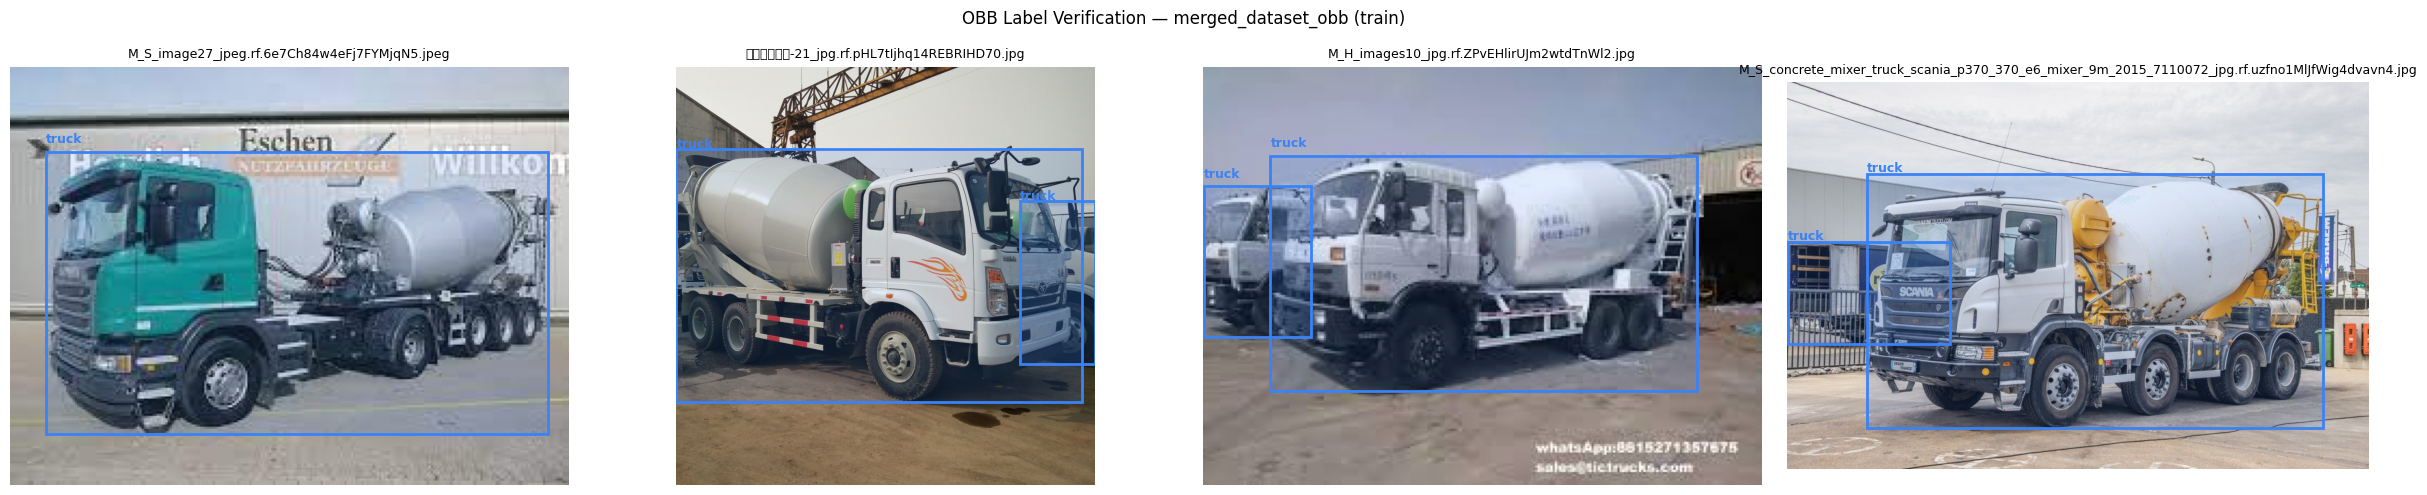

✅ Visualized 4 samples from train/


In [ ]:
# ── Cell 12: Verify merged OBB labels ────────────────────────────────────────
visualize_obb_labels(str(merged_path), num_samples=4, split="train")

## 🎓 PHASE 3 — Two-Stage OBB Training

In [28]:
# ── Cell 13: Run PHASE 3 ─────────────────────────────────────────────────────
print("=" * 65)
print("PHASE 3: Two-Stage OBB Training")
print("=" * 65)

trainer = OBBTrainer(cfg)
trainer.setup_mlflow()
trainer.load()

best_model_path = trainer.train_two_stage(data_yaml_path)

print(f"\n  🏆 Best model saved → {best_model_path}")


PHASE 3: Two-Stage OBB Training
  MLflow URI : file:///c:/%E0%B8%9B%E0%B8%B53/Truck%20detection/Truck-concreate/mlruns
  Loading: yolo26n-obb.pt
  ✅ Model loaded (YOLO)
  frozen 10 param tensors (first 10 layers)

  Stage1_FreezeBackbone — 20 epochs
  Params: 2,652,984 total | 0 trainable (0.0%)
Ultralytics 8.4.37  Python-3.12.10 torch-2.11.0+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=merged_dataset_obb\data.yaml, degrees=45.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

In [29]:
# ── Cell 14: Validate + plot training curves ─────────────────────────────────
print("=" * 65)
print("Validation")
print("=" * 65)
val_results = trainer.validate(best_model_path, data_yaml_path)

plot_training_results("runs/obb/mixer_obb")


Validation
Ultralytics 8.4.37  Python-3.12.10 torch-2.11.0+cpu CPU (12th Gen Intel Core i7-12700H)
YOLO26n-obb summary (fused): 132 layers, 2,446,797 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 112.165.8 MB/s, size: 102.4 KB)
val: Scanning C:\ปี3\Truck detection\Truck-concreate\merged_dataset_obb\valid\labels.cache... 162 images, 22 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 162/162  0.0s
val: C:\3\Truck detection\Truck-concreate\merged_dataset_obb\valid\images\M_D_-id-76299955-type-or_jpg.rf.hzeLFlzwlsgt2RprdHoj.jpg: corrupt JPEG restored and saved
val: C:\3\Truck detection\Truck-concreate\merged_dataset_obb\valid\images\M_M_178-862-wooden-model-concrete-mixer-truck-man_jpg.rf.1ZulK3sJJOhPdyvy4Ixe.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.1it/s 10.0s.1s
                   all        162        220      0.435      0.922      0.569      0.

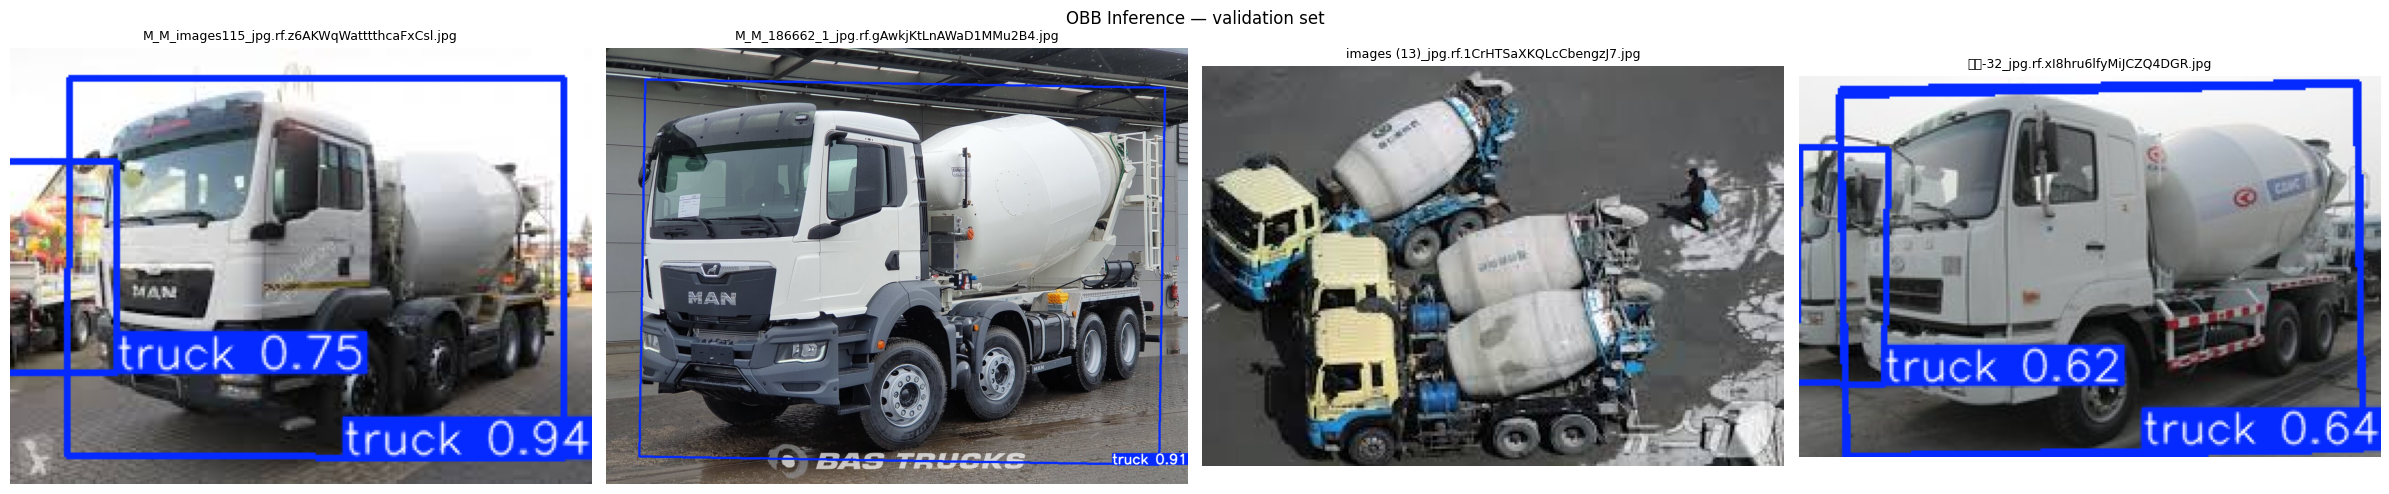

✅ Inference visualized


In [30]:
# ── Cell 15: Quick inference on validation samples ───────────────────────────
infer_model = YOLO(str(best_model_path))
val_images  = find_images(merged_path / "valid" / "images")
samples     = random.sample(val_images, min(4, len(val_images)))

if samples:
    ncols = min(4, len(samples))
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    if ncols == 1: axes = [axes]

    for ax, img_path in zip(axes, samples):
        results  = infer_model(str(img_path), verbose=False, conf=0.25)
        annotated = results[0].plot()
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    plt.suptitle("OBB Inference — validation set", fontsize=12)
    plt.tight_layout()
    plt.show()
    print("✅ Inference visualized")
else:
    print("⚠️  No validation images found")


## 🔄 PHASE 4 — Drum Rotation Detection

In [31]:
# ── Cell 16: Run PHASE 4 on a video ─────────────────────────────────────────
# ┌──────────────────────────────────────────────────────────────────────────┐
# │  Set your video path below before running this cell.                    │
# │  output_video=None  →  no file written (preview only)                   │
# └──────────────────────────────────────────────────────────────────────────┘

INPUT_VIDEO  = "path/to/your/video.mp4"         # ← CHANGE THIS
OUTPUT_VIDEO = str(Path(cfg.output_dir) / "rotation_detection_output.mp4")

if not Path(INPUT_VIDEO).exists():
    print(f"⚠️  Video not found: {INPUT_VIDEO}")
    print("   Please set INPUT_VIDEO to a valid path and re-run this cell.")
else:
    processor = VideoProcessor(best_model_path, cfg)
    summary   = processor.process_video(
        video_path   = INPUT_VIDEO,
        output_path  = OUTPUT_VIDEO,
        show_preview = False,
    )
    print("\n  Summary:")
    for k, v in summary.items():
        print(f"    {k}: {v}")
    print(f"\n  Output video → {OUTPUT_VIDEO}")


⚠️  Video not found: path/to/your/video.mp4
   Please set INPUT_VIDEO to a valid path and re-run this cell.


In [32]:
# ── Cell 17: Live webcam demo (optional) ─────────────────────────────────────
# Run only in a local Jupyter environment with a webcam.
# Stop the cell to exit (Kernel → Interrupt).
#
# Uncomment the block below to enable:

# processor = VideoProcessor(best_model_path, cfg)
# cap = cv2.VideoCapture(0)
# prev_crops = {}
# while True:
#     ret, frame = cap.read()
#     if not ret: break
#     results = processor.model(frame, verbose=False, conf=0.25)
#     annotated = results[0].plot()
#     cv2.imshow("OBB Live", annotated)
#     if cv2.waitKey(1) & 0xFF == ord("q"):
#         break
# cap.release()
# cv2.destroyAllWindows()

print("Webcam demo cell ready — uncomment to run")


Webcam demo cell ready — uncomment to run


## 📦 Export & Deployment

In [33]:
# ── Cell 18: Export to ONNX ──────────────────────────────────────────────────
onnx_path = Path(str(best_model_path).replace(".pt", ".onnx"))

export_model = YOLO(str(best_model_path))
export_model.export(format="onnx", imgsz=cfg.input_size, simplify=True, opset=17)

print(f"✅ ONNX exported → {onnx_path}")
print(f"   Deploy with: cv2.dnn.readNetFromONNX('{onnx_path}')")
print(f"   Or: onnxruntime.InferenceSession('{onnx_path}')")


Ultralytics 8.4.37  Python-3.12.10 torch-2.11.0+cpu CPU (12th Gen Intel Core i7-12700H)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n-obb summary (fused): 132 layers, 2,446,797 parameters, 0 gradients, 5.4 GFLOPs

PyTorch: starting from 'C:\3\Truck detection\Truck-concreate\runs\obb\runs\obb\mixer_obb\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 7) (5.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command 'pip install --no-cache-dir "onnx>=1.12.0,<2.0.0" "onnxslim>=0.1.71" ' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command 'pip install --no-cache-dir "onnx>=1.12.0,<2.0.0" "onnxslim>=0.1.71" ' returned non-zero exit status 1.
WARNING requirements:  Command 'pip install --no-cache-dir "onnx>=1.12.0,<2.0.0" "onnxslim>=0.1.71" ' 

ModuleNotFoundError: No module named 'onnx.defs'

## 📊 Pipeline Summary

In [ ]:
# ── Cell 19: Pipeline summary ─────────────────────────────────────────────────
print("=" * 65)
print("🎉  COMPLETE PIPELINE SUMMARY")
print("=" * 65)

print("\n✅ PHASE 1 — YOLO-World Auto-Labeling")
print(f"   Auto-labeled output : {cfg.auto_labeled_dir}")
print(f"   YOLO-World model    : {cfg.yoloworld_model}")
print(f"   Classes detected    : {cfg.yoloworld_classes}")

print("\n✅ PHASE 2 — Data Fusion")
print(f"   Merged dataset      : {cfg.merged_dir}")
print(f"   data.yaml           : {data_yaml_path}")

print("\n✅ PHASE 3 — Two-Stage OBB Training")
print(f"   Base model          : {cfg.model_name}")
print(f"   Best model          : {best_model_path}")
print(f"   mAP50               : {val_results.box.map50:.4f}")
print(f"   mAP50-95            : {val_results.box.map:.4f}")
print(f"   MLflow UI           : mlflow ui --backend-store-uri {cfg.mlruns_dir}")

print("\n✅ PHASE 4 — Rotation Detection")
print(f"   Flow magnitude thr  : {cfg.flow_mag_threshold}")
print(f"   SSIM threshold      : {cfg.ssim_threshold}")
print(f"   Curl threshold      : {cfg.curl_threshold}")
print(f"   Min drum area (px²) : {cfg.min_drum_area}")

print("\n📂 Output files:")
for p in Path(cfg.output_dir).iterdir():
    print(f"   {p}")

print("\n🚀 Next steps:")
print("   1.  Set INPUT_VIDEO in Cell 16 and run rotation detection")
print("   2.  mlflow ui --backend-store-uri ./mlruns   (view experiments)")
print("   3.  Use exported ONNX for edge deployment")
print("   4.  Tune flow_mag_threshold / ssim_threshold for your site conditions")

print("\n" + "=" * 65)
print("✨  Pipeline complete!")
print("=" * 65)
